## Using Fourier Transform to Uncover Overtone Patterns in Timbres of Different Instruments
To visualise and compare the overtone patterns of all the notes of an octave (middle C to B4), between Cello (Violoncello), Violin, Flute, and Oboe, using its Fourier Transform plots. 

### Importing packages and module

In [2]:
import scipy.io.wavfile as wav
import scipy.signal as ss
import numpy as np
import os
import matplotlib.pyplot as plt

### Checking file info ie. sample rate, data.shape, duration

In [8]:
sample_rate, data = wav.read('sound_data/A-flute.wav')
sample_rate, data #checking data files

(44100,
 array([[ 0.0000000e+00,  0.0000000e+00],
        [-2.5904336e-07, -2.5904336e-07],
        [-9.7212592e-07, -9.7212592e-07],
        ...,
        [ 0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00]], shape=(161670, 2), dtype=float32))

In [9]:
duration_seconds = len(data) / sample_rate
duration_seconds

3.665986394557823

### Trimming data to 1 second
Standardising audio files to 1 second.

In [5]:
folder_path = 'sound_data'
os.makedirs('./trimmed_files')

for old_files in os.listdir(folder_path):
    if old_files.endswith('.wav'):
        file_path = os.path.join(folder_path, old_files)
        sample_rate, data = wav.read(file_path)
        trimmed_data = data[:44100]  # slice the data array to the first 1 second
        trimmed_filename = f"1_{old_files}"
        trimmed_file_path = os.path.join('./trimmed_files', trimmed_filename)
        wav.write(trimmed_file_path, sample_rate, trimmed_data)

        print(f"Trimmed {old_files} and saved as {trimmed_filename}")

Trimmed A#-Flute.wav and saved as 1_A#-Flute.wav
Trimmed A#-Oboe.wav and saved as 1_A#-Oboe.wav
Trimmed A#-Violin.wav and saved as 1_A#-Violin.wav
Trimmed A#-Violoncello.wav and saved as 1_A#-Violoncello.wav
Trimmed A#.wav and saved as 1_A#.wav
Trimmed A-Flute.wav and saved as 1_A-Flute.wav
Trimmed A-Oboe.wav and saved as 1_A-Oboe.wav
Trimmed A-Violin.wav and saved as 1_A-Violin.wav
Trimmed A-Violoncello.wav and saved as 1_A-Violoncello.wav
Trimmed A.wav and saved as 1_A.wav
Trimmed B-Flute.wav and saved as 1_B-Flute.wav
Trimmed B-Oboe.wav and saved as 1_B-Oboe.wav
Trimmed B-Violin.wav and saved as 1_B-Violin.wav
Trimmed B-Violoncello.wav and saved as 1_B-Violoncello.wav
Trimmed B.wav and saved as 1_B.wav
Trimmed C#-Flute.wav and saved as 1_C#-Flute.wav
Trimmed C#-Oboe.wav and saved as 1_C#-Oboe.wav
Trimmed C#-Violin.wav and saved as 1_C#-Violin.wav
Trimmed C#-Violoncello.wav and saved as 1_C#-Violoncello.wav
Trimmed C#.wav and saved as 1_C#.wav
Trimmed C-Flute.wav and saved as 1_C-Flu

### Checking file info for entire folder
Checking that all files in the folder have the correct sample rate (44100), and data shape (44100,2).

In [7]:
trimmed_path = 'trimmed_files'

counter=0 

for files in os.listdir(trimmed_path):
    file_path = os.path.join(trimmed_path, files)
    sample_rate, data = wav.read(file_path)
    if sample_rate == 44100:
        if data.shape == (44100, 2):
            counter+=1 #there probably is a better way to just return true/false values
        else: 
            print('error')
    else:
        print('error')
counter

60

### Plotting time domain graph
Exploratory data analysis to visualise time domain data.

### Plotting FFT signature and peaks
Exploratory data analysis to visualise FFT data.

[ 277.  555.  559.  831. 1111. 1116. 1387. 1664.]
[ 83.2943   113.90605   28.886229  23.535421 147.9686    60.87818
 187.96724   25.75908 ]


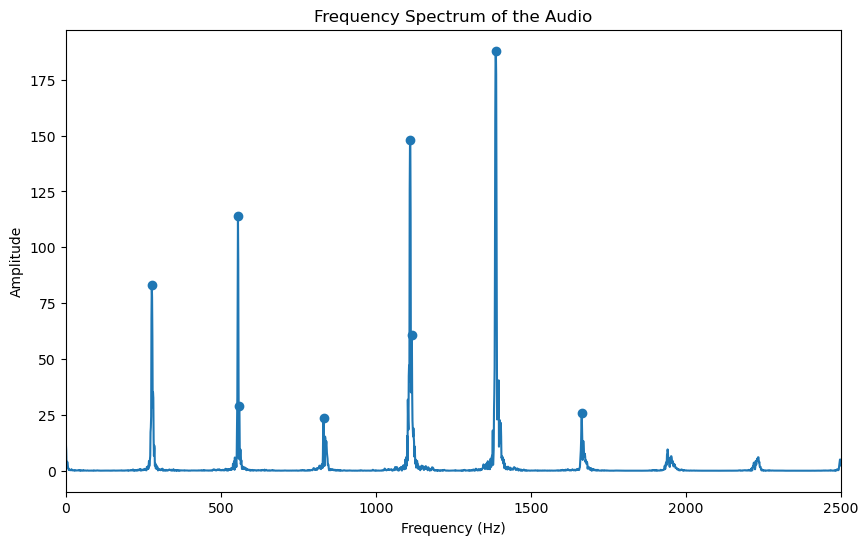

In [20]:
sample_rate, data = wav.read('trimmed_files/1_C#-Oboe.wav')
data = data[:, 0]  # isolate channel 1

# Y-values AMPLITUDE 
fft_data = np.fft.fft(data) # FFT audio signal: array of Y-values in complex numbers
amplitude = np.abs(fft_data) # amplitude spectrum: magnitude in positive Y-values

# X-values CORRESPONDING FREQUENCIES
window_length = len(data)
frequencies = np.fft.fftfreq(window_length, 1 / sample_rate)  # window length, sample spacing = inverse of sample rate

# FINDING PEAKS 
peak_indices, _ = ss.find_peaks(amplitude[:n//2], prominence=20) # find peaks, in positive range 

print(frequencies[peak_indices])
print(amplitude[peak_indices])

# Plotting Peaks 
plt.figure(figsize=(10, 6))
plt.scatter(frequencies[peak_indices],amplitude[peak_indices]) # plot peaks 

# Plotting FFT
plt.plot(frequencies[:n//2], amplitude[:n//2]) # slice to obtain first 22050 elements in the array ie. positive X-values FREQUENCIES
plt.title('Frequency Spectrum of the Audio')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0,2500)
plt.show()

From this plot, we concluded that the primary frequency might not be the highest amplitude signal. For the C# note on the Oboe, the highest amplitude is at the overtone 5x the primary frequency. The timbre of a sound varies with the characteristics (number, frequency and relative intensity of peaks) of the overtones, which are signals higher than the lowest (fundamental) frequency of a sound (University of Minnesota, 2022).
\
\
In this case, while the signal with the greatest amplitude is not the fundamental frquency, the human ear still detects the fundamental frequency as the dominant pitch due to the human hearing sensitivity being better at that frequency range (250-500Hz) compared to higher frequencies (above 1000Hz).
\
\
![](https://www.researchgate.net/profile/Rickye-Heffner/publication/6597029/figure/fig2/AS:667798971895813@1536227090260/Audiogram-showing-the-average-human-threshold-for-pure-tones-obtained-in-a-sound-field.ppm)
\
__Fig. 1:__ Human Audiogram showing the average human threshold for pure tones obtained in a sound field.
\
\
Based on the plot, as well as Fig 1, we determined that the frequency range of interest would be between 200Hz (lowest frequency in data set = 261.63Hz) to 2500Hz, which is 5x the highest fundamental frequency in our data set (493.88). 
\
\
References

- University of Minnesota. (2022, January 1). Timbre. Pressbooks. https://pressbooks.umn.edu/sensationandperception/chapter/timbre/
- Heffner, H. E., & Heffner, R. S. (2007). Hearing ranges of laboratory animals. Journal of the American Association for Laboratory Animal Science : JAALAS, 46(1), 20–22.

### Plotting frequencies against index
To find the range of positive frequency values within the array. We determined that the first 22050 values are positive. 

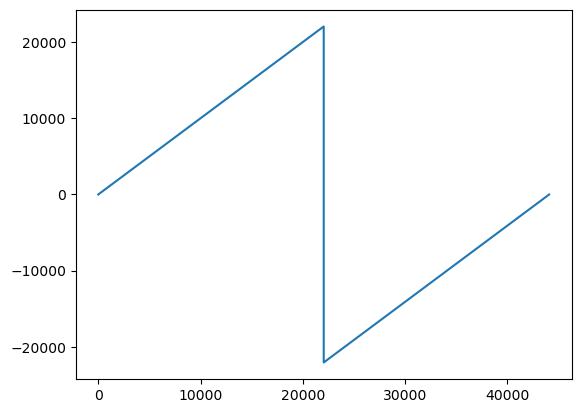

In [19]:
plt.plot(frequencies)

### Check for anomalies

#### Index the highest peak
We expected that the highest peak amplitude (argmax) for the FFT signal will be the fundamental frequency. Using this code, we checked the argmax for all the files and concluded that the entire Oboe data set, and some of the Violin, Cello and Flute data exhibited this anomaly. We printed the index of the argmax along with the multiple (of the fundamental frequency) at which the highest peak is, ie. 3 means the peak is at 3x the fundemental frequency.

In [4]:
ref_pitch = {'1_A#':466.16,
'1_A':440,
'1_B':493.88,
'1_C#':277.18, 
'1_C':261.63,
'1_D#':311.13, 
'1_D':293.66,
'1_E':329.63, 
'1_F#':369.99, 
'1_F':349.23, 
'1_G#':415.30, 
'1_G':392.00
} # dictionary of reference pitches and their frequencies

instruments = ['Oboe.wav', 'Violoncello.wav', 'Flute.wav', 'Violin.wav']

print('File, Peak index, Multiple')

for allinstruments in instruments:
    for allfiles in os.listdir(trimmed_path):
        if allfiles.endswith(allinstruments):
            file_path = os.path.join(trimmed_path, allfiles)
            sample_rate, data = wav.read(file_path)
            data = data[:, 0]
            fft_data = np.fft.fft(data) 
            amplitude = np.abs(fft_data)
               
            central_index = np.argmax(amplitude)
            peak_amplitude = amplitude[central_index]

            letter_name = allfiles.split('-')[0]
            if np.isclose(ref_pitch[letter_name],central_index,atol=5) == False:
                if np.isclose(ref_pitch[letter_name],central_index/2,atol=5) == False:
                    if np.isclose(ref_pitch[letter_name],central_index/3,atol=5) == False:
                        if np.isclose(ref_pitch[letter_name],central_index/4,atol=5) == False:
                            if np.isclose(ref_pitch[letter_name],central_index/5,atol=5) == False:
                                if np.isclose(ref_pitch[letter_name],central_index/6,atol=5) == False:
                                    print('The index is out of the 5x fundemental frequency range')
                            else: print(allinstruments, round(central_index), 5)
                        else: print(allinstruments, round(central_index), 4)
                    else: print(allinstruments, round(central_index), 3)
                else: print(allinstruments, round(central_index), 2)
            else: print(allinstruments, central_index, 1)

File, Peak index, Multiple
Oboe.wav 1395 3
Oboe.wav 1316 3
Oboe.wav 1478 3
Oboe.wav 1387 5
Oboe.wav 1308 5
Oboe.wav 1556 5
Oboe.wav 1468 5
Oboe.wav 1319 4
Oboe.wav 1481 4
Oboe.wav 1397 4
Oboe.wav 1663 4
Oboe.wav 1570 4
Violoncello.wav 466 1
Violoncello.wav 878 2
Violoncello.wav 494 1
Violoncello.wav 279 1
Violoncello.wav 261 1
Violoncello.wav 313 1
Violoncello.wav 295 1
Violoncello.wav 331 1
Violoncello.wav 370 1
Violoncello.wav 350 1
Violoncello.wav 415 1
Violoncello.wav 392 1
Flute.wav 465 1
Flute.wav 439 1
Flute.wav 492 1
Flute.wav 556 2
Flute.wav 262 1
Flute.wav 1253 4
Flute.wav 295 1
Flute.wav 331 1
Flute.wav 370 1
Flute.wav 1404 4
Flute.wav 415 1
Flute.wav 393 1
Violin.wav 468 1
Violin.wav 441 1
Violin.wav 496 1
Violin.wav 556 2
Violin.wav 526 2
Violin.wav 311 1
Violin.wav 294 1
Violin.wav 331 1
Violin.wav 1104 3
Violin.wav 350 1
Violin.wav 417 1
Violin.wav 392 1


#### Correcting these anomalies
Using the multiple derived above, we expected to convert the argmax into the primary frequency by dividing the central index by the multiple. However, the resulting values do not accurately correspond to the actual peak positions. As illustrated below, using Oboe as an example, the 12 tones exhibit slight misalignments, indicating that the true peaks are not exactly at 3x, 4x, or 5x the fundemental frequencies, but rather may occur at values such as 3.1x, 4.9x, etc. Therefore, it is not appropriate to simply divide by 3, 4, 5, and so on.

#### Plot, corrected for anomalies
The peaks are still off alignment from each other. We are unable to normalise the plots to the same X-axis and align the curves to get a mean shape.

In [6]:
oboe_central = {} # dictionary of central indices of Oboe data set

for allfiles in os.listdir(trimmed_path):
    if allfiles.endswith('Oboe.wav'):
        file_path = os.path.join(trimmed_path, allfiles)
        sample_rate, data = wav.read(file_path)
        data = data[:, 0]
        fft_data = np.fft.fft(data) 
        amplitude = np.abs(fft_data)
               
        central_index = np.argmax(amplitude)
        peak_amplitude = amplitude[central_index]

        letter_name = allfiles.split('-')[0]
        if np.isclose(ref_pitch[letter_name],central_index,atol=5) == False:
            if np.isclose(ref_pitch[letter_name],central_index/2,atol=5) == False:
                if np.isclose(ref_pitch[letter_name],central_index/3,atol=5) == False:
                    if np.isclose(ref_pitch[letter_name],central_index/4,atol=5) == False:
                        if np.isclose(ref_pitch[letter_name],central_index/5,atol=5) == False:
                            if np.isclose(ref_pitch[letter_name],central_index/6,atol=5) == False:
                                print('The index is out of the 5x fundemental frequency range')
                        else: oboe_central[allfiles]=(round(central_index/5))
                    else: oboe_central[allfiles]=(round(central_index/4))
                else: oboe_central[allfiles]=(round(central_index/3))
            else: oboe_central[allfiles]=(round(central_index/2))
        else: oboe_central[allfiles]=(central_index)

oboe_central

{'1_A#-Oboe.wav': 465,
 '1_A-Oboe.wav': 439,
 '1_B-Oboe.wav': 493,
 '1_C#-Oboe.wav': 277,
 '1_C-Oboe.wav': 262,
 '1_D#-Oboe.wav': 311,
 '1_D-Oboe.wav': 294,
 '1_E-Oboe.wav': 330,
 '1_F#-Oboe.wav': 370,
 '1_F-Oboe.wav': 349,
 '1_G#-Oboe.wav': 416,
 '1_G-Oboe.wav': 392}

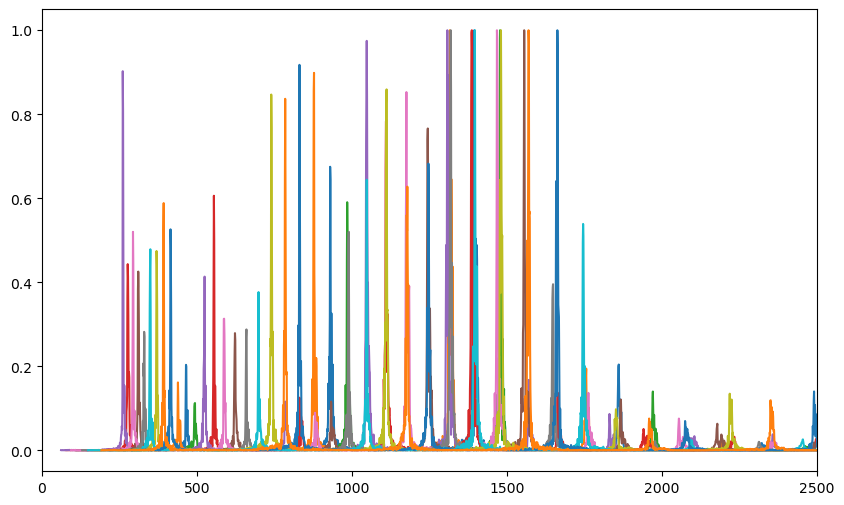

In [9]:
plt.figure(figsize=(10, 6))

trimmed_path = 'trimmed_files'

for allfiles in os.listdir(trimmed_path):
    if allfiles.endswith('Oboe.wav'):
        file_path = os.path.join(trimmed_path, allfiles)
        sample_rate, data = wav.read(file_path)
        data = data[:, 0]
        
        fft_data = np.fft.fft(data) 
        amplitude = np.abs(fft_data)
    
        window_length = len(data)
        frequencies = np.fft.fftfreq(window_length, 1 / sample_rate)
        
        central_index = oboe_central[allfiles]
        peak_amplitude = amplitude[np.argmax(amplitude)]
                
        spliced_f=frequencies[(central_index-200):(central_index+2500)]
        spliced_a=amplitude[(central_index-200):(central_index+2500)]
        normalised_amplitude = spliced_a/peak_amplitude
               
        plt.plot(spliced_f, normalised_amplitude) 

plt.xlim(0,2500)
plt.show()

#### Scatter plot for prominent peaks 
This scatter plot aimed to determine the distribution of peaks within the Oboe data set, as another form of exploratory data analysis. The ss.find_peaks() was used with a prominence of 20. The prominence is how much the peak stands out from the surrounding baseline of the signal. Different values were trialed (1,5,10,20,100) to determine a reasonable prominence that would select obvious peaks and leave out smaller, insignificant peaks. Fundamental frequencies were all normalised to 440, and amplitudes normalised by dividing all the elements in the array by its max value. 
\
\
We found that the rest of the peaks still did not align, possibly as the peaks are not linearly distributed ie. not a constant number of Hz between each peak. However, the first element of the 12 arrays are indeed the fundamental frequencies, confirming our assumption made above. This method also allowed us to reliably determine the index of the fundamental frequency for all files.

[  465   930   934   938  1390  1395  1400  1403  1407  1861 42239 42693
 42697 42700 42705 42710 43162 43166 43170 43635]
[  439   878   882   885  1312  1316  1321  1325  1756 42344 42775 42779
 42784 42788 43215 43218 43222 43661]
[  494   980   985   990  1473  1478  1483  1487  1971 42129 42613 42617
 42622 42627 43110 43115 43120 43606]
[  277   555   559   831  1111  1116  1387  1664 42436 42713 42984 42989
 43269 43541 43545 43823]
[  261   525  1048  1305  1308  1310  1314  1322  1571 42529 42778 42786
 42790 42792 42795 43052 43575 43839]
[  311   623   933  1245  1252  1255  1556  1562  1868 42232 42538 42544
 42845 42848 42855 43167 43477 43789]
[  294   588  1176  1181  1185  1468  1475  1763 42337 42625 42632 42915
 42919 42924 43512 43806]
[  330   660   990   993  1319  1323  1325  1643  1649  1654 42446 42451
 42457 42775 42777 42781 43107 43110 43440 43770]
[  370   740  1112  1478  1481  2219 41881 42619 42622 42988 43360 43730]
[  350   699  1048  1397  1400  1402  

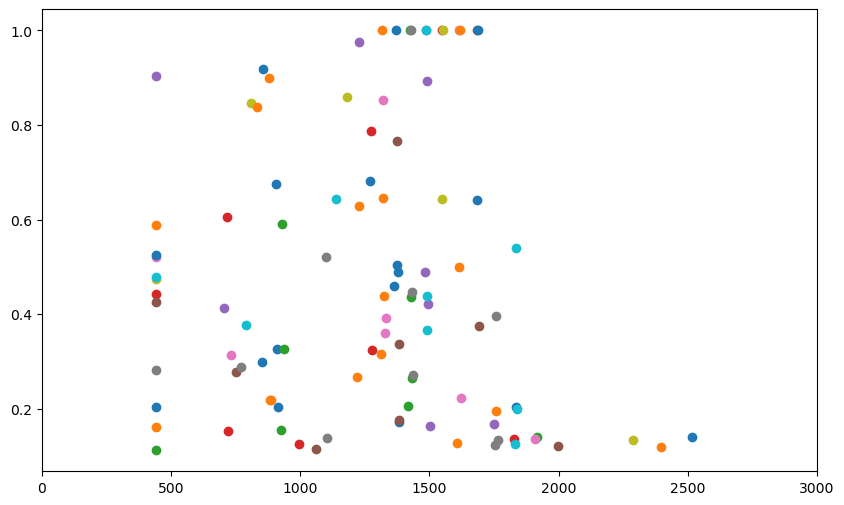

In [12]:
plt.figure(figsize=(10, 6))

for allfiles in os.listdir(trimmed_path):
    if allfiles.endswith('Oboe.wav'):
        file_path = os.path.join(trimmed_path, allfiles)
        sample_rate, data = wav.read(file_path)
        data = data[:, 0]
        
        fft_data = np.fft.fft(data) 
        amplitude = np.abs(fft_data)
    
        window_length = len(data)
        frequencies = np.fft.fftfreq(window_length, 1 / sample_rate)
        
        peak_amplitude = amplitude[np.argmax(amplitude)]
    
        peaks_set, _ = ss.find_peaks(amplitude, prominence=20) # index of all peaks 
        print(peaks_set)
        
        central_index = peaks_set[0] # fundamental frequency
        amplitude_set = amplitude[peaks_set] # amplitude of all peaks
        normalised_frequency = np.array(peaks_set)-(central_index-440) # shift all plots to start at 440
             
        plt.scatter(normalised_frequency, amplitude_set/peak_amplitude)

plt.xlim(0,3000)
plt.show()

## Mean curves of 4 instruments
We tried to mean the curves of the 12 tones of an instrument to get an "average" curve. We did this for all 4 instruments, and compared them in this graph. We normalised the Y axis by dividing the amplitude data by the max amplitude; and the X axis, by selecting a window from -200 to +2500 of the central index. This is to align all the fundamental frequencies and obtain arrays on the same length. We realised that the data is not meaningful as the peaks of the different tones are misaligned, hence, they would be cancelled out when we mean. 

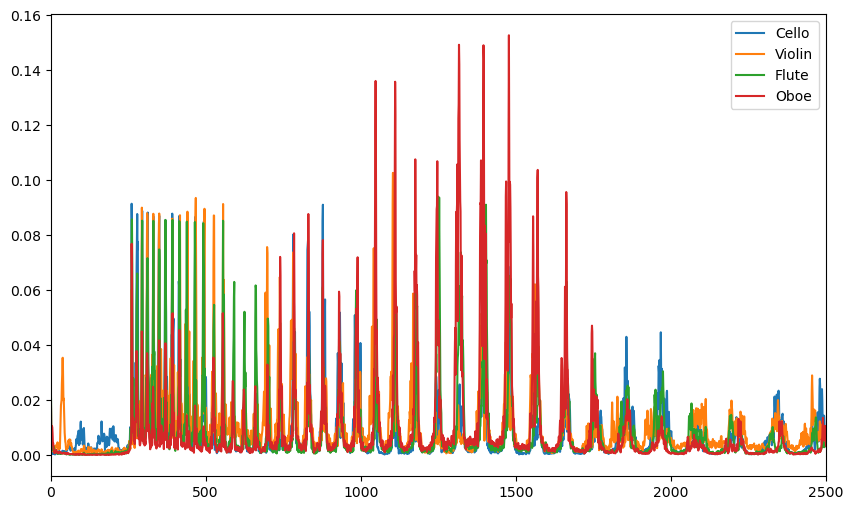

In [21]:
plt.figure(figsize=(10, 6))
arrays_instru = {
    'Violoncello' : [],
    'Violin' : [],
    'Flute' : [],
    'Oboe' : [],} # dictionary to store the arrays of the different instruments

trimmed_path = 'trimmed_files'

for allfiles in os.listdir(trimmed_path):    
    for instrument in arrays_instru:  # assigns each key in the dictionary to the variable "instrument"
        if allfiles.endswith(f'{instrument}.wav'):
            file_path = os.path.join(trimmed_path, allfiles)
            sample_rate, data = wav.read(file_path)
            data = data[:, 0]  # isolate channel 1
                
            # Y-values AMPLITUDE 
            fft_data = np.fft.fft(data) 
            amplitude = np.abs(fft_data) 

            # X-values CORRESPONDING FREQUENCIES
            window_length = len(data)
            frequencies = np.fft.fftfreq(window_length, 1 / sample_rate)  # window length, sample spacing = inverse of sample rate
            
            # NORMALISE X-AXIS, taking delta(-) = 200, delta(+) = 2500
            central_index = np.argmax(amplitude)
            peak_amplitude = amplitude[central_index]

            normalised_amplitude = amplitude/peak_amplitude
            
            spliced_f=frequencies[(central_index-200):(central_index+2500)]
            spliced_a=normalised_amplitude[(central_index-200):(central_index+2500)]
            
            arrays_instru[instrument].append(normalised_amplitude)
            
# Mean of Instruments 
means = {} # save into a dictionary

for inst, arrays_in in arrays_instru.items():  # unpacking keys and values pairs 
    means[inst] = np.mean(arrays_in, axis=0)   # adding a new key-value pair to "means" dictionary for each instrument

# Plotting
plt.plot(means['Violoncello'], label='Cello')
plt.plot(means['Violin'], label='Violin')
plt.plot(means['Flute'], label='Flute')
plt.plot(means['Oboe'], label='Oboe')

plt.legend()
plt.xlim(0,2500)
plt.show()

## Final plot: comparing different instruments across 12 tones
After gathering all the information from above, we determined that the curve for each note may be unique, and cannot be compared all together. We decided to plot 12 graphs, representing the 12 tones in our data set, 4 lines each representing the 4 instruments, Oboe, Flute, Cello and Violin, in order to compare their curve contours. 
\
We also normalised the amplitudes by determining their loudness, by integrating the FFT curve, and dividing the amplitudes by loudness.

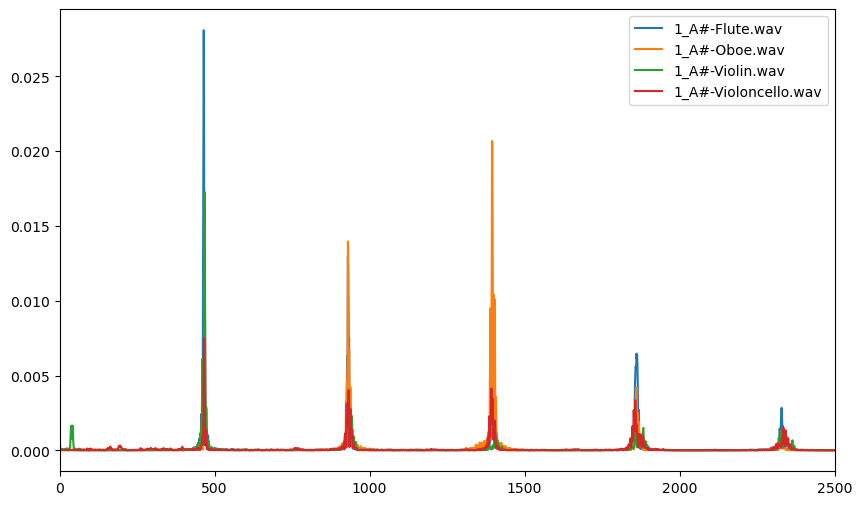

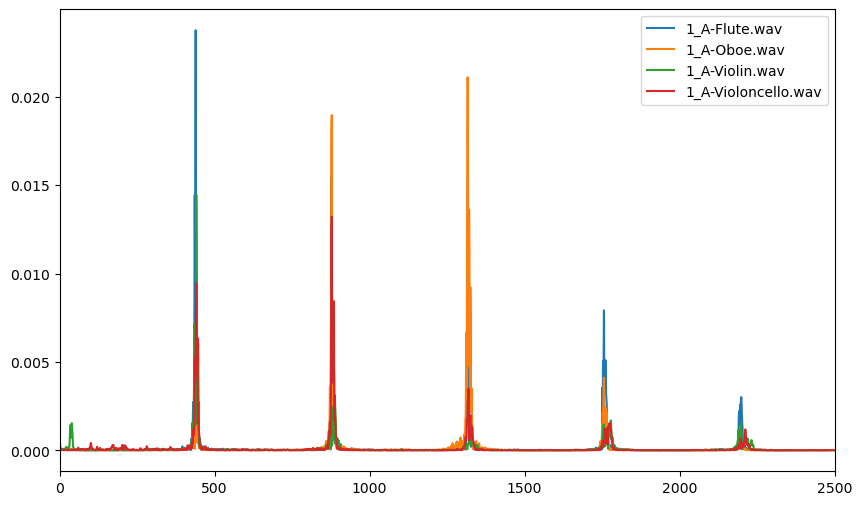

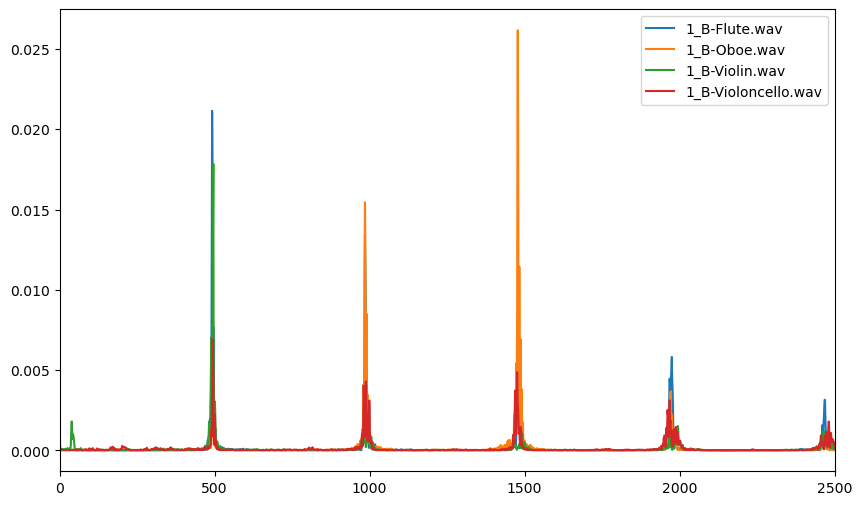

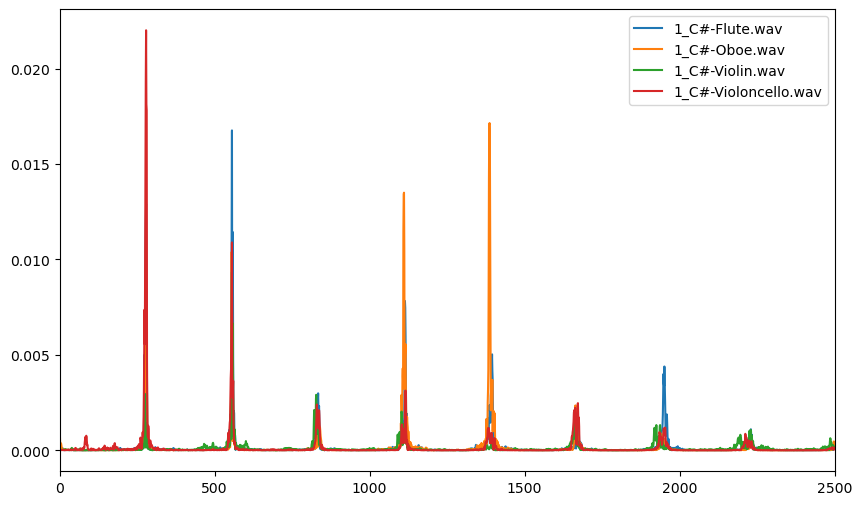

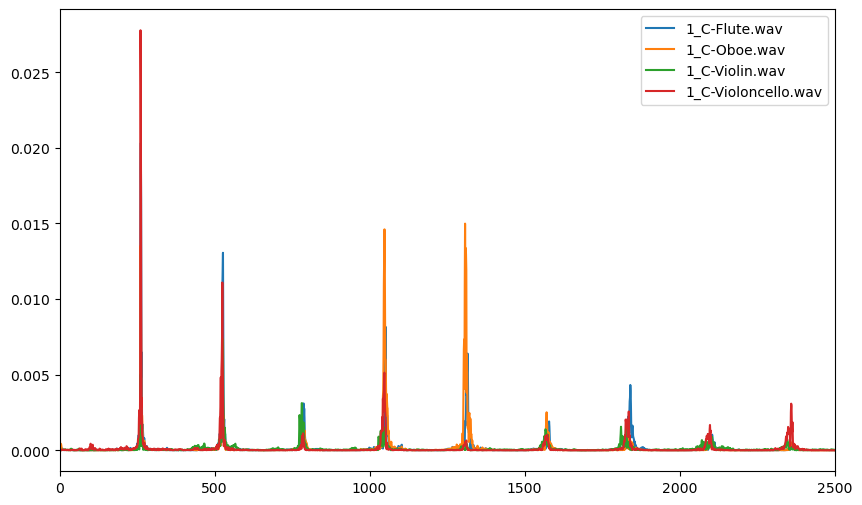

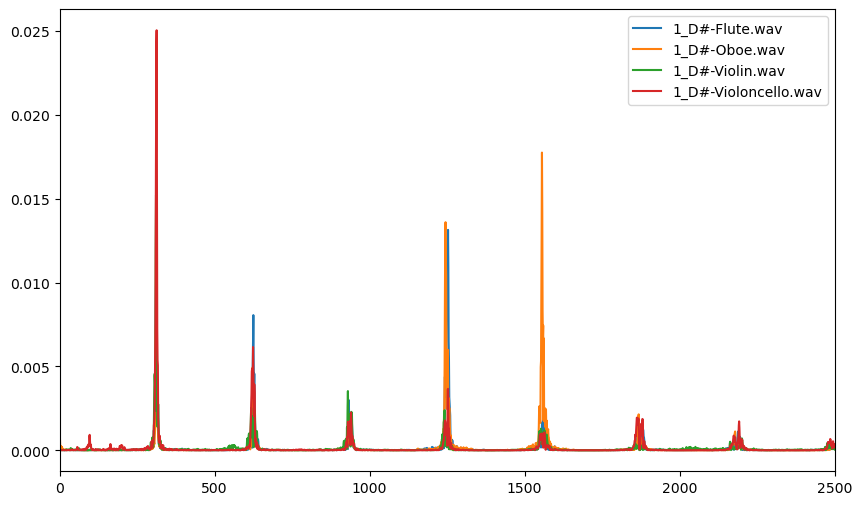

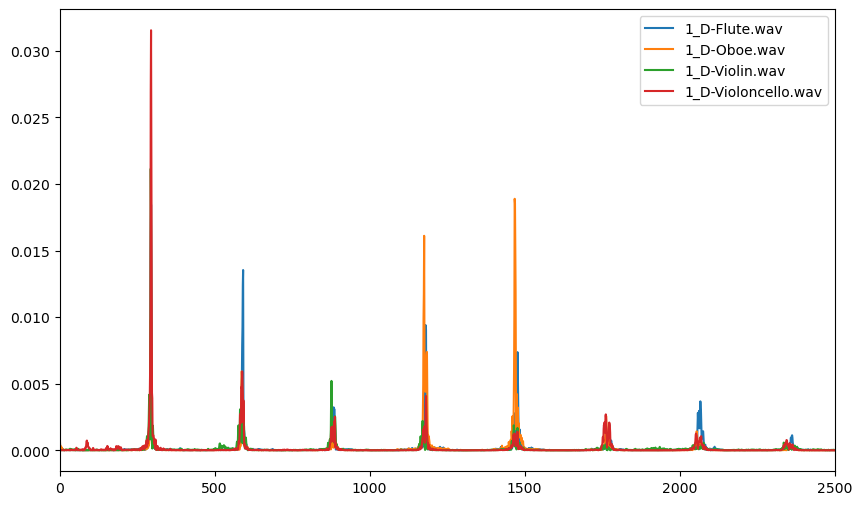

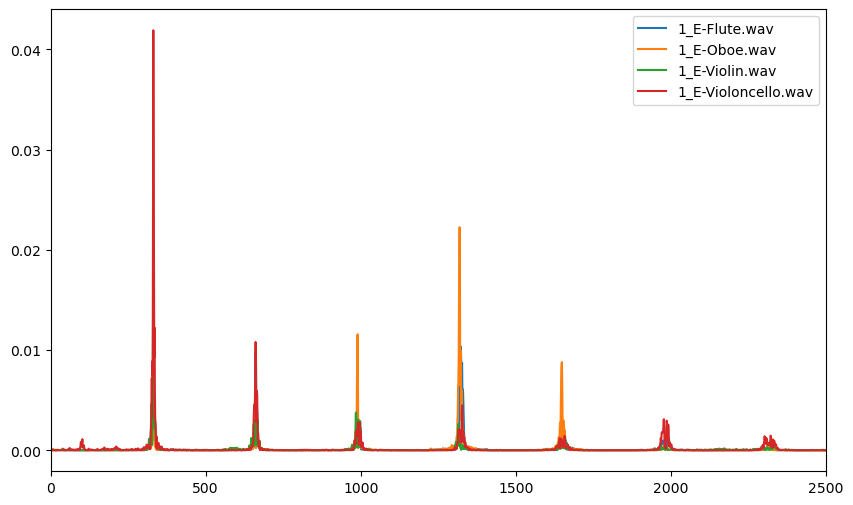

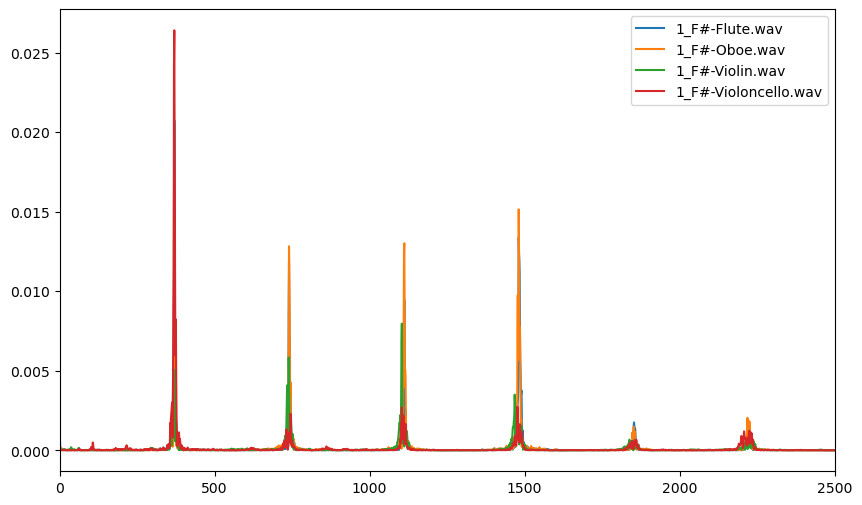

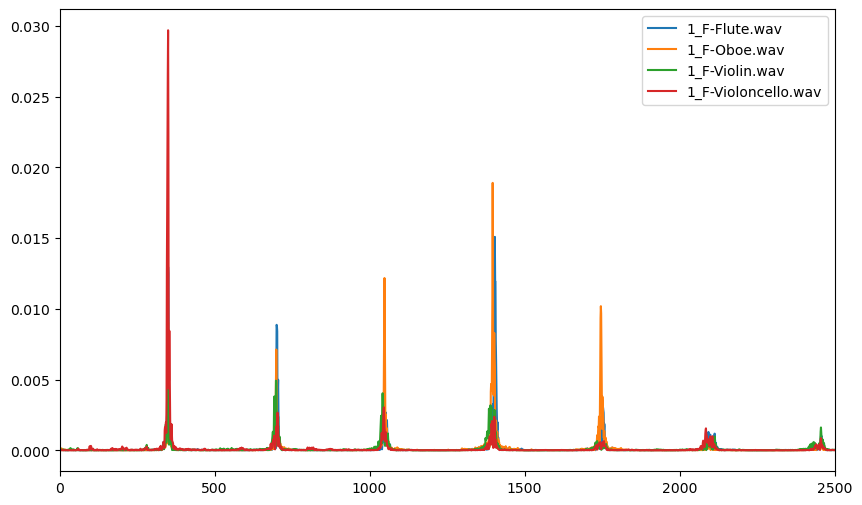

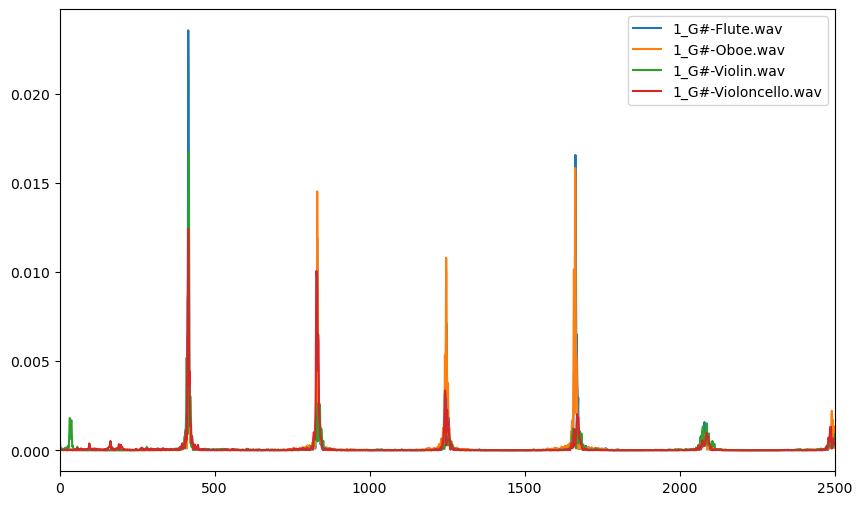

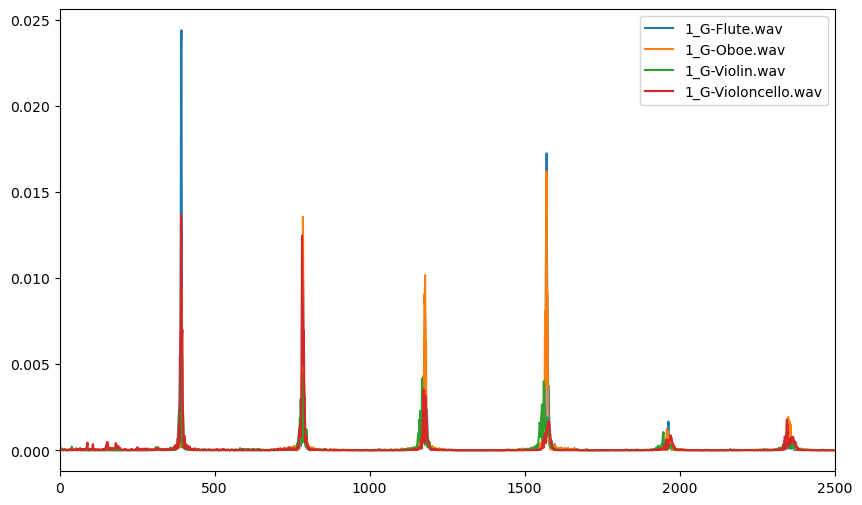

In [15]:
pitch = ['1_A#-',
'1_A-',
'1_B-',
'1_C#-', 
'1_C-',
'1_D#-', 
'1_D-',
'1_E-', 
'1_F#-', 
'1_F-', 
'1_G#-', 
'1_G-'] # 12 tones 

trimmed_path = 'trimmed_files'

for pitch_in in pitch: # iterate each pitch - this loops 12 times
    plt.figure(figsize=(10, 6)) 
    for allfiles in os.listdir(trimmed_path): 
        if allfiles.startswith(pitch_in): # finds all files of the same pitch
            file_path = os.path.join(trimmed_path, allfiles)
            sample_rate, data = wav.read(file_path)
            data = data[:, 0]  # isolate channel 1
    
            # Y-values AMPLITUDE 
            fft_data = np.fft.fft(data) # # FFT audio signal: array of Y-values in complex numbers
            amplitude = np.abs(fft_data) # amplitude spectrum: magnitude in positive Y-values

            # X-values CORRESPONDING FREQUENCIES
            window_length = len(data)
            frequencies = np.fft.fftfreq(window_length, 1 / sample_rate)  # window length, sample spacing = inverse of sample rate

            # Normalise amplitude for loudness
            loudness = np.trapezoid(amplitude, frequencies) # integrate area under the curve
            normalised_amplitude = amplitude/loudness # amplitude normalised for difference in loudness
            
            # PLOTTING
            plt.plot(frequencies[:window_length//2], normalised_amplitude[:window_length//2], label = f"{allfiles}") # slice to obtain first 22050 elements in the array ie. positive X-values FREQUENCIES
            plt.legend()
            plt.xlim(0,2500) # 5x the highest primary frequency
            
    plt.show()

In conclusion, our project successfully generated 12 plots, showing that for notes G and above (G to B4), the flute exhibits the highest amplitude at the fundamental frequency, while for notes below G (middle to F#), the violin shows the highest amplitude at the fundamental frequency. This allows us to differentiate between the flute and violin based on their amplitude characteristics at the fundamental frequency at least.

In [42]:
primary_peaks = []

for pitch_in in pitch: # iterate each pitch, loops 12 times
    for allfiles in os.listdir(trimmed_path): 
        if allfiles.startswith(pitch_in): # finds all files of the same pitch
            file_path = os.path.join(trimmed_path, allfiles)
            sample_rate, data = wav.read(file_path)
            data = data[:, 0]  # isolate channel 1
    
            # Y-values AMPLITUDE 
            fft_data = np.fft.fft(data) # FFT audio signal (time-domain data) [array of Y-values in complex numbers]
            amplitude = np.abs(fft_data) # amplitude spectrum (gives the magnitude in positive Y-values)
            
            # X-values CORRESPONDING FREQUENCIES
            n = len(data)
            frequencies = np.fft.fftfreq(n, 1 / sample_rate)  # window length, sample spacing = inverse of sample rate

            # Normalise amplitude for loudness
            normalised_amplitude = amplitude/np.trapezoid(amplitude, frequencies)

            # Slices 1x / 2x / 3x
            primary_peak = np.max(normalised_amplitude[200:500])
            primary_peaks.append(primary_peak)
            
            # ORDER: flute, oboe, violin, violoncello

for i in range(0, 48, 4):
    true_peak, peak_index = np.max(primary_peaks[i:i+4]), np.argmax(primary_peaks[i:i+4])
    print(true_peak, peak_index)

0.02808772458530744 0
0.023763580216376222 0
0.021144574717907212 0
0.022012758156864022 3
0.027778114923075206 3
0.02505352326749972 3
0.03153753965867584 3
0.04189718495158656 3
0.02640078988213398 3
0.029698171797177174 3
0.023549329029570902 0
0.024377985134379127 0


In the future, the comparison of Fourier transform graphs between instruments can be automated and streamlined instead of using visual interpretations. 
Additionally, more octaves can be analysed as our work only explores the notes in one octave. Other instruments can also be compared alongside the 4 instruments.

## Mean curves of 4 instruments

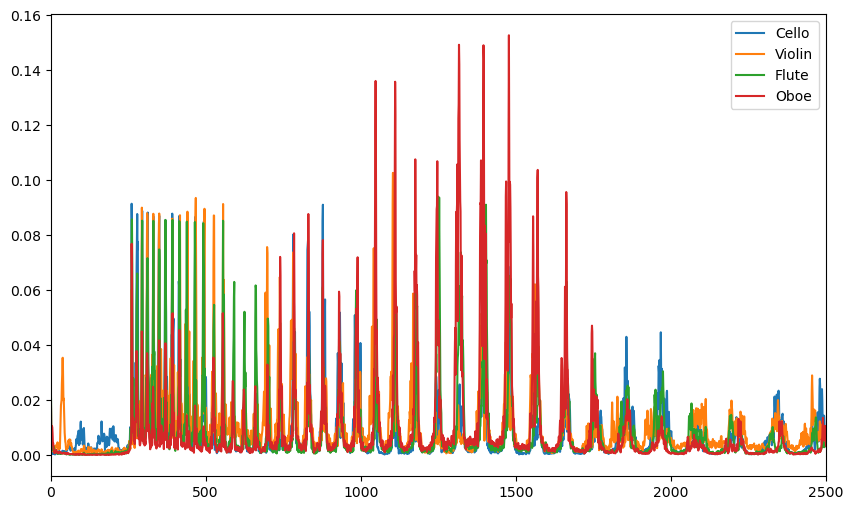

In [20]:
plt.figure(figsize=(10, 6))
arrays_instru = {
    'Violoncello' : [],
    'Violin' : [],
    'Flute' : [],
    'Oboe' : [],} # dictionary to store the arrays of the different instruments

trimmed_path = 'trimmed_files'

for allfiles in os.listdir(trimmed_path):    
    for instrument in arrays_instru:  # assigns each key in the dictionary to the variable "instrument"
        if allfiles.endswith(f'{instrument}.wav'):
            file_path = os.path.join(trimmed_path, allfiles)
            sample_rate, data = wav.read(file_path)
            data = data[:, 0]  # isolate channel 1
                
            # Y-values AMPLITUDE 
            fft_data = np.fft.fft(data) 
            amplitude = np.abs(fft_data) 

            # X-values CORRESPONDING FREQUENCIES
            window_length = len(data)
            frequencies = np.fft.fftfreq(window_length, 1 / sample_rate)  # window length, sample spacing = inverse of sample rate
            
            # NORMALISE X-AXIS, taking delta(-) = 200, delta(+) = 2500
            central_index = np.argmax(amplitude)
            peak_amplitude = amplitude[central_index]

            normalised_amplitude = amplitude/peak_amplitude
            
            spliced_f=frequencies[(central_index-200):(central_index+2500)]
            spliced_a=normalised_amplitude[(central_index-200):(central_index+2500)]
            
            arrays_instru[instrument].append(normalised_amplitude)
            
# Mean of Instruments 
means = {} # save into a dictionary

for inst, arrays_in in arrays_instru.items():  # unpacking keys and values pairs 
    means[inst] = np.mean(arrays_in, axis=0)   # adding a new key-value pair to "means" dictionary for each instrument

# Plotting
plt.plot(means['Violoncello'], label='Cello')
plt.plot(means['Violin'], label='Violin')
plt.plot(means['Flute'], label='Flute')
plt.plot(means['Oboe'], label='Oboe')

plt.legend()
plt.xlim(0,2500)
plt.show()